## Backward Calculation of Implied Probabilities - Start: Aug 2025

In [1]:
import pandas as pd
import numpy as np

cme_aug_2025 = pd.read_csv("../../data/raw/CME/CME_AUG_2025.csv")
cme_aug_2025 = cme_aug_2025.reset_index(drop = True)
cme_aug_2025["time"] = pd.to_datetime(cme_aug_2025["time"],unit="s") 

In [2]:
cme_aug_2025

,time,open,high,low,close,Volume
0,2025-03-02 23:00:00,96.0250,96.0250,96.015,96.015,100
1,2025-03-02 23:02:00,96.0100,96.0100,96.010,96.010,32
2,2025-03-02 23:04:00,96.0100,96.0100,96.010,96.010,3
3,2025-03-02 23:49:00,96.0050,96.0050,96.005,96.005,281
4,2025-03-02 23:50:00,96.0050,96.0050,96.005,96.005,17
...,...,...,...,...,...,...
30838,2025-08-01 20:55:00,95.6825,95.6825,95.680,95.680,482
30839,2025-08-01 20:56:00,95.6800,95.6800,95.680,95.680,12
30840,2025-08-01 20:57:00,95.6800,95.6800,95.680,95.680,23
30841,2025-08-01 20:58:00,95.6800,95.6800,95.680,95.680,121


## CME End: Jul 2025

In [3]:
cme_jul_2025 = pd.read_csv("../../data/raw/CME/CME_JUL_2025.csv")
cme_jul_2025 = cme_jul_2025.reset_index(drop = True)
cme_jul_2025["time"] = pd.to_datetime(cme_jul_2025["time"],unit="s") 

In [4]:
cme_jul_2025

,time,open,high,low,close,Volume
0,2025-02-02 23:00:00,95.905,95.905,95.870,95.875,1694
1,2025-02-02 23:01:00,95.875,95.875,95.870,95.870,244
2,2025-02-02 23:02:00,95.875,95.875,95.870,95.875,31
3,2025-02-02 23:04:00,95.875,95.875,95.875,95.875,4
4,2025-02-02 23:05:00,95.875,95.875,95.875,95.875,621
...,...,...,...,...,...,...
28766,2025-07-31 17:05:00,95.670,95.670,95.670,95.670,15
28767,2025-07-31 18:51:00,95.670,95.670,95.670,95.670,1
28768,2025-07-31 18:55:00,95.670,95.670,95.670,95.670,17
28769,2025-07-31 19:39:00,95.670,95.670,95.670,95.670,13


## Merge

In [5]:
aug = cme_aug_2025.copy()
aug["time"] = pd.to_datetime(aug["time"], unit="s")

if aug["time"].dt.tz is None:
    aug["time"] = aug["time"].dt.tz_localize("UTC")
else:
    aug["time"] = aug["time"].dt.tz_convert("UTC")

aug = aug.sort_values("time").set_index("time")
aug = aug.add_suffix("_aug_2025")

jul = cme_jul_2025.copy()
jul["time"] = pd.to_datetime(jul["time"], unit="s")

if jul["time"].dt.tz is None:
    jul["time"] = jul["time"].dt.tz_localize("UTC")
else:
    jul["time"] = jul["time"].dt.tz_convert("UTC")

jul = jul.sort_values("time").set_index("time")
jul = jul.add_suffix("_jul_2025")

In [6]:
final_df = aug.join(jul, how="left")

In [7]:
final_df = final_df.dropna()

In [8]:
final_df = final_df.reset_index()

In [9]:
final_df

,time,open_aug_2025,high_aug_2025,low_aug_2025,close_aug_2025,Volume_aug_2025,open_jul_2025,high_jul_2025,low_jul_2025,close_jul_2025,Volume_jul_2025
0,2025-03-02 23:00:00+00:00,96.0250,96.0250,96.0150,96.0150,100,95.935,95.935,95.925,95.925,405.0
1,2025-03-02 23:02:00+00:00,96.0100,96.0100,96.0100,96.0100,32,95.925,95.925,95.925,95.925,25.0
2,2025-03-03 00:40:00+00:00,96.0050,96.0050,96.0050,96.0050,156,95.915,95.915,95.915,95.915,9.0
3,2025-03-03 00:43:00+00:00,96.0050,96.0050,96.0050,96.0050,102,95.915,95.915,95.915,95.915,6.0
4,2025-03-03 01:44:00+00:00,96.0050,96.0050,96.0050,96.0050,24,95.915,95.915,95.915,95.915,13.0
...,...,...,...,...,...,...,...,...,...,...,...
14257,2025-07-31 15:54:00+00:00,95.6725,95.6725,95.6725,95.6725,15,95.670,95.670,95.670,95.670,1.0
14258,2025-07-31 17:05:00+00:00,95.6750,95.6750,95.6750,95.6750,4375,95.670,95.670,95.670,95.670,15.0
14259,2025-07-31 18:51:00+00:00,95.6750,95.6750,95.6750,95.6750,2,95.670,95.670,95.670,95.670,1.0
14260,2025-07-31 19:39:00+00:00,95.6750,95.6750,95.6750,95.6750,75,95.670,95.670,95.670,95.670,13.0


## Calculate Implied Probabilities

In [10]:
meeting_day = 30
days_in_july = 31

N = meeting_day           
M = days_in_july - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()

imp_df["effr_avg_jul"] = 100 - final_df["close_jul_2025"]
imp_df["effr_avg_aug"] = 100 - final_df["close_aug_2025"]

imp_df["effr_start_aug"] = imp_df["effr_avg_aug"]
imp_df["effr_end_jul"] = imp_df["effr_start_aug"]
imp_df["volume"] = final_df["Volume_jul_2025"]


In [11]:
imp_df["effr_start_jul"] = (
    imp_df["effr_avg_jul"] - (M / (N + M)) * imp_df["effr_end_jul"]
) / (N / (N + M))

In [12]:
imp_df["delta_effr"] = imp_df["effr_end_jul"] - imp_df["effr_start_jul"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]

states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [13]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

In [14]:
imp_df

,time,effr_avg_jul,effr_avg_aug,effr_start_aug,effr_end_jul,volume,effr_start_jul,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2025-03-02 23:00:00+00:00,4.075,3.9850,3.9850,3.9850,405.0,4.078000,-0.093000,-0.372000,-1.0,0.628000,0.0,0.0,0.0,0.372000,0.628000,0.0,0.0,0.0,0.0
1,2025-03-02 23:02:00+00:00,4.075,3.9900,3.9900,3.9900,25.0,4.077833,-0.087833,-0.351333,-1.0,0.648667,0.0,0.0,0.0,0.351333,0.648667,0.0,0.0,0.0,0.0
2,2025-03-03 00:40:00+00:00,4.085,3.9950,3.9950,3.9950,9.0,4.088000,-0.093000,-0.372000,-1.0,0.628000,0.0,0.0,0.0,0.372000,0.628000,0.0,0.0,0.0,0.0
3,2025-03-03 00:43:00+00:00,4.085,3.9950,3.9950,3.9950,6.0,4.088000,-0.093000,-0.372000,-1.0,0.628000,0.0,0.0,0.0,0.372000,0.628000,0.0,0.0,0.0,0.0
4,2025-03-03 01:44:00+00:00,4.085,3.9950,3.9950,3.9950,13.0,4.088000,-0.093000,-0.372000,-1.0,0.628000,0.0,0.0,0.0,0.372000,0.628000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14257,2025-07-31 15:54:00+00:00,4.330,4.3275,4.3275,4.3275,1.0,4.330083,-0.002583,-0.010333,-1.0,0.989667,0.0,0.0,0.0,0.010333,0.989667,0.0,0.0,0.0,0.0
14258,2025-07-31 17:05:00+00:00,4.330,4.3250,4.3250,4.3250,15.0,4.330167,-0.005167,-0.020667,-1.0,0.979333,0.0,0.0,0.0,0.020667,0.979333,0.0,0.0,0.0,0.0
14259,2025-07-31 18:51:00+00:00,4.330,4.3250,4.3250,4.3250,1.0,4.330167,-0.005167,-0.020667,-1.0,0.979333,0.0,0.0,0.0,0.020667,0.979333,0.0,0.0,0.0,0.0
14260,2025-07-31 19:39:00+00:00,4.330,4.3250,4.3250,4.3250,13.0,4.330167,-0.005167,-0.020667,-1.0,0.979333,0.0,0.0,0.0,0.020667,0.979333,0.0,0.0,0.0,0.0


## Calculating Implied Probabilities for June 2025

In [16]:
cme_jun_2025 = pd.read_csv("../../data/raw/CME/CME_JUN_2025.csv")
cme_jun_2025 = cme_jun_2025.reset_index(drop = True)
cme_jun_2025["time"] = pd.to_datetime(cme_jun_2025["time"],unit="s") 

In [17]:
cme_jun_2025

,time,open,high,low,close,Volume
0,2025-01-26 23:26:00,95.855,95.855,95.855,95.855,21
1,2025-01-27 00:56:00,95.855,95.855,95.855,95.855,14
2,2025-01-27 00:57:00,95.855,95.855,95.855,95.855,30
3,2025-01-27 01:07:00,95.860,95.860,95.860,95.860,36
4,2025-01-27 01:10:00,95.860,95.860,95.860,95.860,84
...,...,...,...,...,...,...
20263,2025-06-30 19:35:00,95.670,95.670,95.670,95.670,6
20264,2025-06-30 19:38:00,95.670,95.670,95.670,95.670,12
20265,2025-06-30 20:00:00,95.670,95.670,95.670,95.670,4
20266,2025-06-30 20:29:00,95.670,95.670,95.670,95.670,2


## Merge June and July

In [33]:
jul = imp_df[["time","effr_start_jul"]].copy()
jul = jul.sort_values("time").set_index("time")

jun = cme_jun_2025.copy()
jun["time"] = pd.to_datetime(jun["time"], unit="s")

if jun["time"].dt.tz is None:
    jun["time"] = jun["time"].dt.tz_localize("UTC")
else:
    jun["time"] = jun["time"].dt.tz_convert("UTC")

jun = jun.sort_values("time").set_index("time")
jun = jun.add_suffix("_jun_2025")

In [34]:
jul_aligned = jul.reindex(jun.index, method="ffill")


final_df = pd.concat([jun, jul_aligned ], axis=1)
final_df = final_df.reset_index()

In [35]:
final_df

,time,open_jun_2025,high_jun_2025,low_jun_2025,close_jun_2025,Volume_jun_2025,effr_start_jul
0,2025-01-26 23:26:00+00:00,95.855,95.855,95.855,95.855,21,NaN
1,2025-01-27 00:56:00+00:00,95.855,95.855,95.855,95.855,14,NaN
2,2025-01-27 00:57:00+00:00,95.855,95.855,95.855,95.855,30,NaN
3,2025-01-27 01:07:00+00:00,95.860,95.860,95.860,95.860,36,NaN
4,2025-01-27 01:10:00+00:00,95.860,95.860,95.860,95.860,84,NaN
...,...,...,...,...,...,...,...
20263,2025-06-30 19:35:00+00:00,95.670,95.670,95.670,95.670,6,4.331667
20264,2025-06-30 19:38:00+00:00,95.670,95.670,95.670,95.670,12,4.331667
20265,2025-06-30 20:00:00+00:00,95.670,95.670,95.670,95.670,4,4.331667
20266,2025-06-30 20:29:00+00:00,95.670,95.670,95.670,95.670,2,4.331667


## IMP rates calculation

In [37]:
meeting_day = 18
days_in_june = 30

N = meeting_day           
M = days_in_june - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()

imp_df["effr_avg_jun"] = 100 - final_df["close_jun_2025"]

imp_df["effr_end_jun"] = final_df["effr_start_jul"]
imp_df["volume"] = final_df["Volume_jun_2025"]


In [39]:
imp_df = imp_df.dropna()

In [41]:
imp_df["effr_start_jun"] = (
    imp_df["effr_avg_jun"] - (M / (N + M)) * imp_df["effr_end_jun"]
) / (N / (N + M))

In [42]:
imp_df["delta_effr"] = imp_df["effr_end_jun"] - imp_df["effr_start_jun"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]

states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [43]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

In [44]:
imp_df

,time,effr_avg_jun,effr_end_jun,volume,effr_start_jun,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
4006,2025-03-02 23:00:00+00:00,4.180,4.078000,54,4.248000,-0.170000,-0.680000,-1.0,0.320000,0.0,0.0,0.0,0.680000,0.320000,0.000000,0.0,0.0,0.0
4007,2025-03-02 23:03:00+00:00,4.180,4.077833,12,4.248111,-0.170278,-0.681111,-1.0,0.318889,0.0,0.0,0.0,0.681111,0.318889,0.000000,0.0,0.0,0.0
4008,2025-03-02 23:07:00+00:00,4.185,4.077833,20,4.256444,-0.178611,-0.714444,-1.0,0.285556,0.0,0.0,0.0,0.714444,0.285556,0.000000,0.0,0.0,0.0
4009,2025-03-02 23:09:00+00:00,4.185,4.077833,30,4.256444,-0.178611,-0.714444,-1.0,0.285556,0.0,0.0,0.0,0.714444,0.285556,0.000000,0.0,0.0,0.0
4010,2025-03-02 23:10:00+00:00,4.185,4.077833,3,4.256444,-0.178611,-0.714444,-1.0,0.285556,0.0,0.0,0.0,0.714444,0.285556,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20263,2025-06-30 19:35:00+00:00,4.330,4.331667,6,4.328889,0.002778,0.011111,0.0,0.011111,0.0,0.0,0.0,0.000000,0.988889,0.011111,0.0,0.0,0.0
20264,2025-06-30 19:38:00+00:00,4.330,4.331667,12,4.328889,0.002778,0.011111,0.0,0.011111,0.0,0.0,0.0,0.000000,0.988889,0.011111,0.0,0.0,0.0
20265,2025-06-30 20:00:00+00:00,4.330,4.331667,4,4.328889,0.002778,0.011111,0.0,0.011111,0.0,0.0,0.0,0.000000,0.988889,0.011111,0.0,0.0,0.0
20266,2025-06-30 20:29:00+00:00,4.330,4.331667,2,4.328889,0.002778,0.011111,0.0,0.011111,0.0,0.0,0.0,0.000000,0.988889,0.011111,0.0,0.0,0.0


## Filter Based on Decision Date


In [45]:
fomc_2025_utc = {
    "January 2025": pd.Timestamp("2025-01-29 19:00:00", tz="UTC"),
    "March 2025": pd.Timestamp("2025-03-19 18:00:00", tz="UTC"),
    "May 2025": pd.Timestamp("2025-05-07 18:00:00", tz="UTC"),
    "June 2025": pd.Timestamp("2025-06-18 18:00:00", tz="UTC"),
    "July 2025": pd.Timestamp("2025-07-30 18:00:00", tz="UTC"),
    "September 2025": pd.Timestamp("2025-09-17 18:00:00", tz="UTC"),
    "October 2025": pd.Timestamp("2025-10-29 19:00:00", tz="UTC"),
    "December 2025": pd.Timestamp("2025-12-10 19:00:00", tz="UTC"),
}

In [46]:
def filter_up_to_announcement(df, announcement_dict):

    if df.empty:
        return df
    last_timestamp = df["time"].iloc[-1]
    last_month_year = last_timestamp.strftime("%B %Y")

    if last_month_year in announcement_dict:
        cutoff_time = announcement_dict[last_month_year]
        filtered_df = df[df["time"] <= cutoff_time]
        return filtered_df
    else:
        print(
            f"Warning: '{last_month_year}' not found in the announcement dictionary"
        )
        return df

In [47]:
imp_df_fil = filter_up_to_announcement(imp_df,fomc_2025_utc)

In [48]:
imp_df_fil

,time,effr_avg_jun,effr_end_jun,volume,effr_start_jun,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
4006,2025-03-02 23:00:00+00:00,4.1800,4.078000,54,4.248000,-0.170000,-0.680000,-1.0,0.320000,0.0,0.0,0.0,0.680000,0.320000,0.0,0.0,0.0,0.0
4007,2025-03-02 23:03:00+00:00,4.1800,4.077833,12,4.248111,-0.170278,-0.681111,-1.0,0.318889,0.0,0.0,0.0,0.681111,0.318889,0.0,0.0,0.0,0.0
4008,2025-03-02 23:07:00+00:00,4.1850,4.077833,20,4.256444,-0.178611,-0.714444,-1.0,0.285556,0.0,0.0,0.0,0.714444,0.285556,0.0,0.0,0.0,0.0
4009,2025-03-02 23:09:00+00:00,4.1850,4.077833,30,4.256444,-0.178611,-0.714444,-1.0,0.285556,0.0,0.0,0.0,0.714444,0.285556,0.0,0.0,0.0,0.0
4010,2025-03-02 23:10:00+00:00,4.1850,4.077833,3,4.256444,-0.178611,-0.714444,-1.0,0.285556,0.0,0.0,0.0,0.714444,0.285556,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20052,2025-06-18 17:28:00+00:00,4.3300,4.326167,1,4.332556,-0.006389,-0.025556,-1.0,0.974444,0.0,0.0,0.0,0.025556,0.974444,0.0,0.0,0.0,0.0
20053,2025-06-18 17:48:00+00:00,4.3275,4.326167,10,4.328389,-0.002222,-0.008889,-1.0,0.991111,0.0,0.0,0.0,0.008889,0.991111,0.0,0.0,0.0,0.0
20054,2025-06-18 17:49:00+00:00,4.3275,4.326167,10,4.328389,-0.002222,-0.008889,-1.0,0.991111,0.0,0.0,0.0,0.008889,0.991111,0.0,0.0,0.0,0.0
20055,2025-06-18 17:51:00+00:00,4.3275,4.326167,107,4.328389,-0.002222,-0.008889,-1.0,0.991111,0.0,0.0,0.0,0.008889,0.991111,0.0,0.0,0.0,0.0


## Visualization

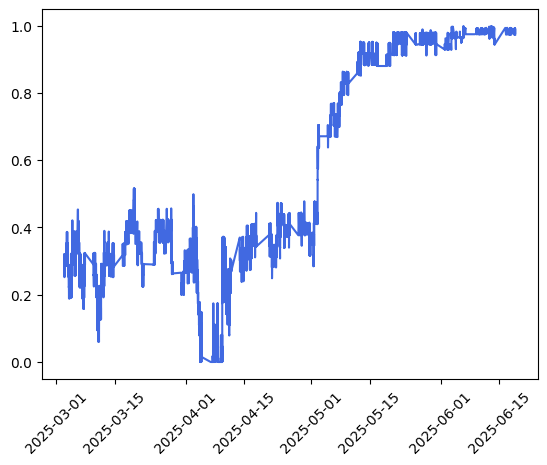

In [49]:
import matplotlib.pyplot as plt

plt.plot(imp_df_fil["time"],imp_df_fil['prob_no_change'], color='royalblue', linewidth=1.5)
plt.xticks(rotation=45)
plt.show()

## Export Data as CSV

In [50]:
import os
DATA_DIR = "../../data/processed/CME_implied_probabilities"
filename = "CME_IMP_JUN_2025.csv"
path = os.path.join(DATA_DIR, filename)
imp_df_fil.to_csv(path,index=False)